# Where Are the Bonds?

In the optimised allocation results, bonds tend to vanish (or collapse to near-zero weight) in the
bootstrapped samplers while retaining meaningful weight under the IID/Cholesky sampler.
This notebook investigates two candidate explanations:

1. **Lower expected (real) returns.** If the block-bootstrap data implies lower nominal bond returns
   and/or higher inflation, the real bond return may be negligible or negative, removing any
   incentive to hold bonds.

2. **Inflation correlation.** If bonds co-move strongly with inflation at multi-year horizons they
   provide poor real-wealth insurance for an inflation-linked spending plan. This effect can
   be masked at the 1-year horizon but grow substantially over longer holding periods due to
   the serial dependence preserved in the block-bootstrap procedure.

**Structure**
- Section 1 — Average returns per sampler (nominal and real)
- Section 2 — Volatility and Sharpe ratio per sampler
- Section 3 — Pairwise asset correlation per sampler
- Section 4 — Correlation with inflation at horizons 1, 2, 3, 5, 10, 15 years

Asset ordering in `.npy` files: `[Bills, Bonds, Equities, CPI]`

In [18]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from itertools import product as iproduct

DATA_DIR = Path('../Data')
PLOTS_DIR = Path('./Plots')
PLOTS_DIR.mkdir(exist_ok=True)

# Asset order matches asset_class_order.txt and .npy column order
ASSET_NAMES = ['Bills', 'Bonds', 'Equities']   # columns 0-2 in .npy (col 3 = CPI)
ALL_NAMES   = ['Bills', 'Bonds', 'Equities', 'CPI']

SAMPLER_KEYS    = ['iid', 'bb_1870', 'bb_1950']
SAMPLER_LABELS  = {
    'iid':     'IID / Cholesky',
    'bb_1870': 'Block Bootstrap\n(1870–2020)',
    'bb_1950': 'Block Bootstrap\n(1950–2020)',
}
SAMPLER_COLORS  = {'iid': '#4c78a8', 'bb_1870': '#f58518', 'bb_1950': '#e45756'}
ASSET_COLORS    = {'Bills': '#72b7b2', 'Bonds': '#f58518', 'Equities': '#54a24b'}

HORIZONS = [1, 2, 3, 5, 10]

In [19]:
# ---------------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------------

# --- IID parameters --------------------------------------------------------
er_df   = pd.read_csv(DATA_DIR / 'IID Data/Final/expected_returns.csv')
cov_df  = pd.read_csv(DATA_DIR / 'IID Data/Final/covariance.csv', index_col=0)

iid_means = er_df.iloc[0].values                         # [Bills, Bonds, Equities, CPI]
iid_cov   = cov_df.values                                # 4×4
iid_std   = np.sqrt(np.diag(iid_cov))                   # [std_Bills, ..., std_CPI]
iid_corr  = np.corrcoef(iid_cov, rowvar=False)          # from covariance -> correlation
# numpy corrcoef expects data rows, not a cov matrix; use the proper way:
d = iid_std
iid_corr  = iid_cov / np.outer(d, d)                    # 4×4 correlation matrix

print("IID means:", dict(zip(ALL_NAMES, np.round(iid_means * 100, 3))))
print("IID std:  ", dict(zip(ALL_NAMES, np.round(iid_std * 100, 3))))

# --- Block bootstrap data --------------------------------------------------
bb_1870_data = np.load(DATA_DIR / 'Returns/Final/block_bootstrapped.npy')
bb_1950_data = np.load(DATA_DIR / 'Returns/Final/block_bootstrapped_1950.npy')

print(f"\nBlock bootstrap 1870 shape: {bb_1870_data.shape}  (n_scenarios, n_timesteps, n_assets+1)")
print(f"Block bootstrap 1950 shape: {bb_1950_data.shape}")

# Summary stats from bootstrap data (mean and std over all scenario-year pairs)
bb_1870_means = bb_1870_data.mean(axis=(0, 1))   # [Bills, Bonds, Equities, CPI]
bb_1950_means = bb_1950_data.mean(axis=(0, 1))
bb_1870_std   = bb_1870_data.reshape(-1, 4).std(axis=0, ddof=1)
bb_1950_std   = bb_1950_data.reshape(-1, 4).std(axis=0, ddof=1)

# Store in dicts for convenience
means = {'iid': iid_means, 'bb_1870': bb_1870_means, 'bb_1950': bb_1950_means}
stds  = {'iid': iid_std,   'bb_1870': bb_1870_std,   'bb_1950': bb_1950_std}

# --- JST annual data (for historical correlation check) --------------------
jst = pd.read_csv(DATA_DIR / 'Returns/Processed/jst_return_data.csv')
jst = (
    jst[['year', 'iso', 'bill_rate', 'bond_tr', 'eq_tr', 'cpi_return']]
    .dropna()
    .rename(columns={'bill_rate': 'Bills', 'bond_tr': 'Bonds',
                     'eq_tr': 'Equities', 'cpi_return': 'CPI'})
    .sort_values(['iso', 'year'])
    .reset_index(drop=True)
)
print(f"\nJST rows: {len(jst)}, years {jst['year'].min()}–{jst['year'].max()}, "
      f"{jst['iso'].nunique()} countries")

IID means: {'Bills': np.float64(1.24), 'Bonds': np.float64(2.847), 'Equities': np.float64(7.873), 'CPI': np.float64(2.5)}
IID std:   {'Bills': np.float64(2.735), 'Bonds': np.float64(5.719), 'Equities': np.float64(13.888), 'CPI': np.float64(1.603)}

Block bootstrap 1870 shape: (469217, 40, 4)  (n_scenarios, n_timesteps, n_assets+1)
Block bootstrap 1950 shape: (463912, 40, 4)

JST rows: 2167, years 1871–2020, 16 countries


---
## Section 1 — Average Returns (Nominal and Real)

C:\Users\CallumDavidson\AppData\Local\Temp\ipykernel_14980\3684315209.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([SAMPLER_LABELS[k] for k in SAMPLER_KEYS],


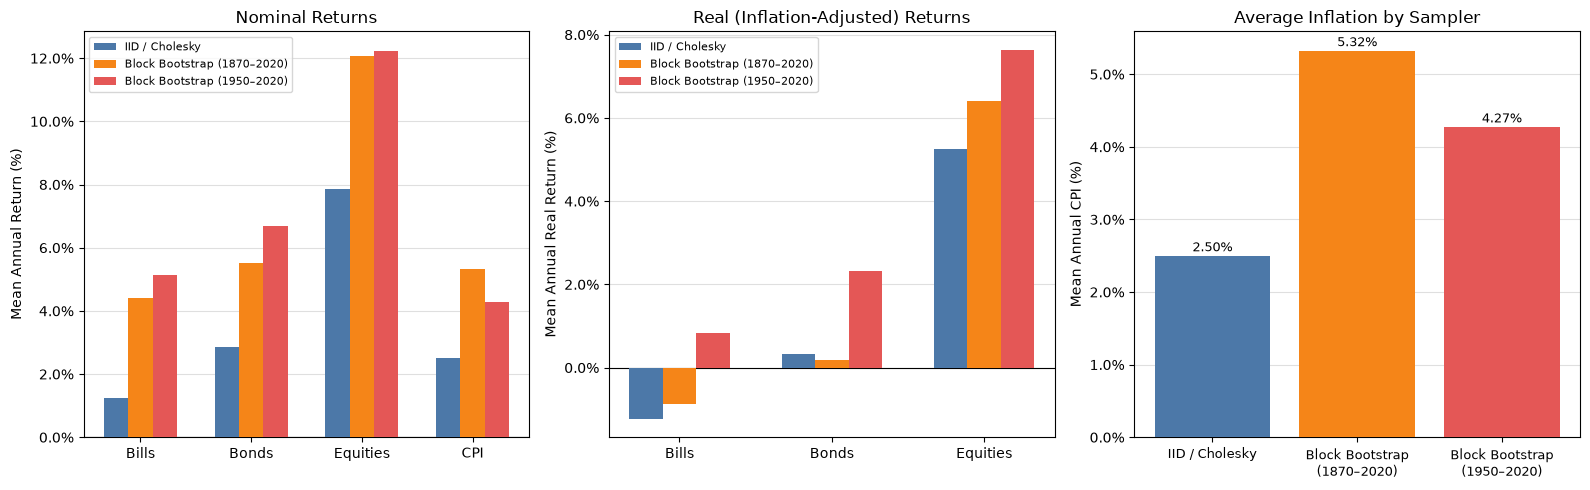

In [47]:
def real_return(nominal, inflation):
    """Geometric real return."""
    return (1 + nominal) / (1 + inflation) - 1

import textwrap

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x    = np.arange(len(ALL_NAMES))
w    = 0.22
offsets = np.array([-1, 0, 1]) * w

# --- Nominal returns -------------------------------------------------------
ax = axes[0]
for i, key in enumerate(SAMPLER_KEYS):
    ax.bar(x + offsets[i], means[key] * 100, w,
           label=SAMPLER_LABELS[key].replace('\n', ' '),
           color=SAMPLER_COLORS[key], zorder=3)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(ALL_NAMES)
ax.set_ylabel('Mean Annual Return (%)')
ax.set_title('Nominal Returns')
ax.grid(axis='y', alpha=0.4, zorder=0)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.legend(fontsize=8)

# --- Real returns ----------------------------------------------------------
ax = axes[1]
for i, key in enumerate(SAMPLER_KEYS):
    infl = means[key][3]
    real = [real_return(means[key][j], infl) for j in range(3)]   # Bills, Bonds, Equities
    ax.bar(np.arange(3) + offsets[i], np.array(real) * 100, w,
           label=SAMPLER_LABELS[key].replace('\n', ' '),
           color=SAMPLER_COLORS[key], zorder=3)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(np.arange(3)); ax.set_xticklabels(ASSET_NAMES)
ax.set_ylabel('Mean Annual Real Return (%)')
ax.set_title('Real (Inflation-Adjusted) Returns')
ax.grid(axis='y', alpha=0.4, zorder=0)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.legend(fontsize=8)

# --- Inflation level -------------------------------------------------------
ax = axes[2]
inf_vals = [means[k][3] * 100 for k in SAMPLER_KEYS]
bars = ax.bar(SAMPLER_KEYS, inf_vals,
              color=[SAMPLER_COLORS[k] for k in SAMPLER_KEYS], zorder=3)
ax.set_xticklabels([SAMPLER_LABELS[k] for k in SAMPLER_KEYS],
                   rotation=0, ha='center', fontsize=9)
ax.set_ylabel('Mean Annual CPI (%)')
ax.set_title('Average Inflation by Sampler')
ax.grid(axis='y', alpha=0.4, zorder=0)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
for bar, val in zip(bars, inf_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{val:.2f}%', ha='center', va='bottom', fontsize=9)

# plt.suptitle('Mean Returns Across Samplers', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'where_are_bonds__returns.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 2 — Volatility and Sharpe Ratio

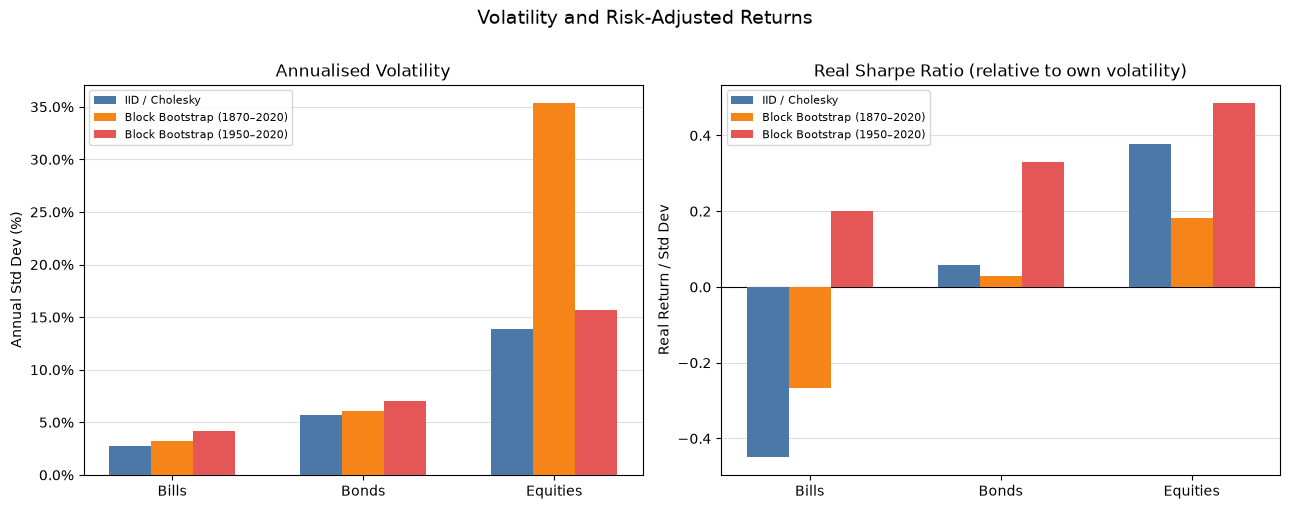

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Annualised standard deviation -----------------------------------------
ax = axes[0]
x  = np.arange(3)   # Bills, Bonds, Equities only
for i, key in enumerate(SAMPLER_KEYS):
    ax.bar(x + offsets[i], stds[key][:3] * 100, w,
           label=SAMPLER_LABELS[key].replace('\n', ' '),
           color=SAMPLER_COLORS[key], zorder=3)
ax.set_xticks(x); ax.set_xticklabels(ASSET_NAMES)
ax.set_ylabel('Annual Std Dev (%)')
ax.set_title('Annualised Volatility')
ax.grid(axis='y', alpha=0.4, zorder=0)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
ax.legend(fontsize=8)

# --- Real Sharpe ratio (excess return over inflation / std) ----------------
ax = axes[1]
for i, key in enumerate(SAMPLER_KEYS):
    infl = means[key][3]
    sharpe = [(real_return(means[key][j], infl)) / stds[key][j]
              for j in range(3)]
    ax.bar(x + offsets[i], sharpe, w,
           label=SAMPLER_LABELS[key].replace('\n', ' '),
           color=SAMPLER_COLORS[key], zorder=3)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(ASSET_NAMES)
ax.set_ylabel('Real Return / Std Dev')
ax.set_title('Real Sharpe Ratio (relative to own volatility)')
ax.grid(axis='y', alpha=0.4, zorder=0)
ax.legend(fontsize=8)

plt.suptitle('Volatility and Risk-Adjusted Returns', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'where_are_bonds__sharpe.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 3 — Pairwise Asset Correlation (1-year)

C:\Users\CallumDavidson\AppData\Local\Temp\ipykernel_14980\616388777.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


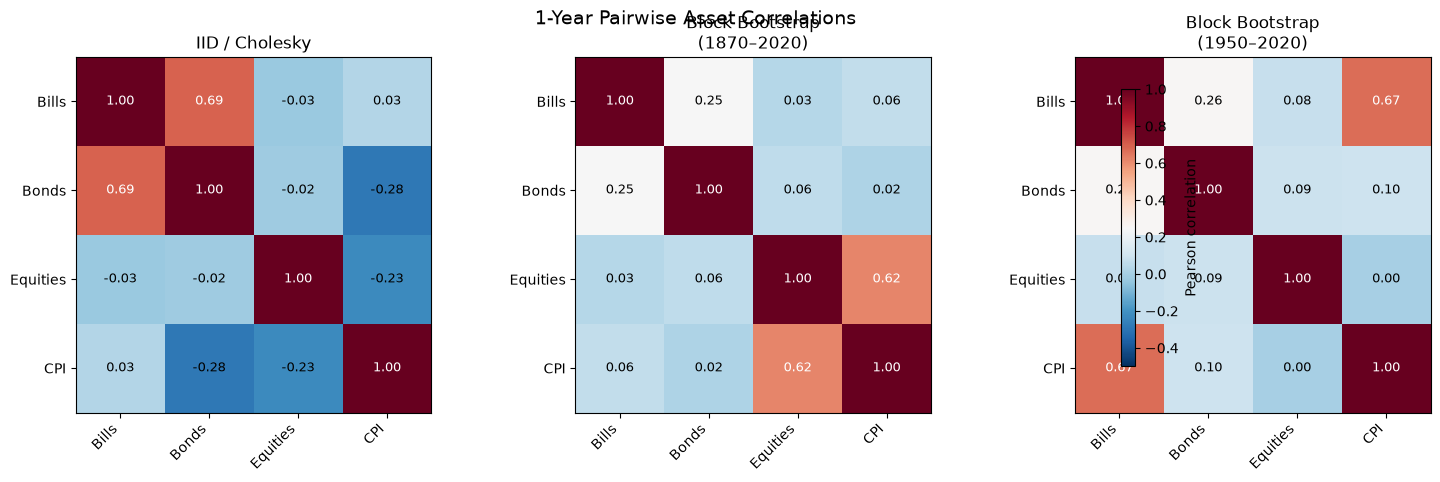

In [22]:
def corr_from_data(data):
    """Compute correlation matrix from (n_scenarios, n_timesteps, n_cols) array."""
    flat = data.reshape(-1, data.shape[2])   # (N, n_cols)
    return np.corrcoef(flat, rowvar=False)   # (n_cols, n_cols)


corr_matrices = {
    'iid':     iid_corr,
    'bb_1870': corr_from_data(bb_1870_data),
    'bb_1950': corr_from_data(bb_1950_data),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
vmin, vmax = -0.5, 1.0
cmap = 'RdBu_r'

for ax, key in zip(axes, SAMPLER_KEYS):
    C = corr_matrices[key]
    im = ax.imshow(C, vmin=vmin, vmax=vmax, cmap=cmap)
    ax.set_xticks(range(4)); ax.set_xticklabels(ALL_NAMES, rotation=45, ha='right')
    ax.set_yticks(range(4)); ax.set_yticklabels(ALL_NAMES)
    ax.set_title(SAMPLER_LABELS[key])
    for i, j in iproduct(range(4), range(4)):
        ax.text(j, i, f'{C[i, j]:.2f}', ha='center', va='center', fontsize=9,
                color='white' if abs(C[i, j]) > 0.5 else 'black')

plt.colorbar(im, ax=axes, shrink=0.8, label='Pearson correlation')
plt.suptitle('1-Year Pairwise Asset Correlations', fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'where_are_bonds__corr_1yr.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4 — Correlation with Inflation at Multiple Horizons

For each sampler we compute the Pearson correlation between the *k*-year compounded
return of each asset class and the *k*-year compounded inflation rate, using all
overlapping *k*-year windows within the block-bootstrap scenario set.

For the IID/Cholesky sampler the correlation is analytically constant across horizons
(IID returns have linearly scaling covariance, so the correlation ratio is preserved),
so we show it as a horizontal reference line drawn from the 1-year covariance matrix.

In [23]:
def horizon_correlations(data, horizons):
    """
    Correlation of each asset's k-year compounded return with k-year compounded
    inflation, for each horizon k.

    Parameters
    ----------
    data : ndarray, shape (n_scenarios, n_timesteps, n_assets+1)
        Last column is inflation (CPI annual return).
    horizons : list[int]

    Returns
    -------
    dict {horizon: ndarray of shape (n_assets,)}
    """
    n_scenarios, n_timesteps, n_cols = data.shape
    n_assets = n_cols - 1
    result = {}

    for k in horizons:
        asset_obs = []   # list of (n_scenarios,) arrays, one per window
        infl_obs  = []

        for t in range(0, n_timesteps - k + 1):            # overlapping windows
            window      = data[:, t:t + k, :]              # (n_scenarios, k, n_cols)
            compounded  = np.prod(1.0 + window, axis=1) - 1.0   # (n_scenarios, n_cols)
            asset_obs.append(compounded[:, :-1])            # (n_scenarios, n_assets)
            infl_obs.append(compounded[:, -1])              # (n_scenarios,)

        # Stack: (N_windows * n_scenarios, ...)
        asset_mat = np.concatenate(asset_obs, axis=0)   # (N, n_assets)
        infl_vec  = np.concatenate(infl_obs,  axis=0)   # (N,)

        corr_row = np.array([
            np.corrcoef(asset_mat[:, j], infl_vec)[0, 1]
            for j in range(n_assets)
        ])
        result[k] = corr_row   # [corr_bills, corr_bonds, corr_equities]

    return result


# Compute for both block bootstrap datasets
print("Computing horizon correlations for Block Bootstrap 1870…")
corr_1870 = horizon_correlations(bb_1870_data, HORIZONS)
print("Computing horizon correlations for Block Bootstrap 1950…")
corr_1950 = horizon_correlations(bb_1950_data, HORIZONS)

# IID: 1-year correlation from covariance matrix (constant across horizons)
iid_corr_with_cpi = iid_corr[:3, 3]   # [Bills-CPI, Bonds-CPI, Equities-CPI]
print("\nIID 1-year correlations with CPI:",
      dict(zip(ASSET_NAMES, np.round(iid_corr_with_cpi, 3))))

Computing horizon correlations for Block Bootstrap 1870…
Computing horizon correlations for Block Bootstrap 1950…

IID 1-year correlations with CPI: {'Bills': np.float64(0.032), 'Bonds': np.float64(-0.283), 'Equities': np.float64(-0.23)}


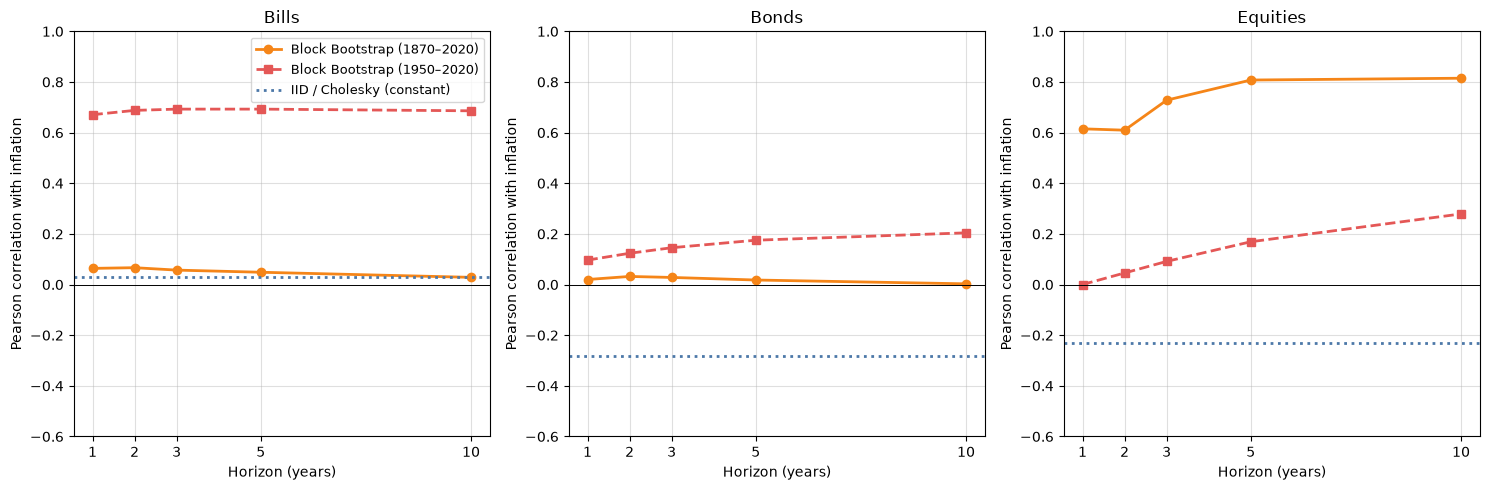

In [48]:
# Plot: one panel per asset class, showing correlation vs horizon
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)

for col, (ax, asset_idx, asset_name) in enumerate(
        zip(axes, range(3), ASSET_NAMES)):

    # Block bootstrap 1870
    y_1870 = [corr_1870[k][asset_idx] for k in HORIZONS]
    ax.plot(HORIZONS, y_1870, 'o-', color=SAMPLER_COLORS['bb_1870'],
            label='Block Bootstrap (1870–2020)', lw=2, ms=6)

    # Block bootstrap 1950
    y_1950 = [corr_1950[k][asset_idx] for k in HORIZONS]
    ax.plot(HORIZONS, y_1950, 's--', color=SAMPLER_COLORS['bb_1950'],
            label='Block Bootstrap (1950–2020)', lw=2, ms=6)

    # IID: horizontal line (constant across horizons)
    ax.axhline(iid_corr_with_cpi[asset_idx],
               color=SAMPLER_COLORS['iid'], lw=2, ls=':',
               label='IID / Cholesky (constant)')

    ax.axhline(0, color='black', lw=0.7)
    ax.set_xlabel('Horizon (years)')
    ax.set_ylabel('Pearson correlation with inflation')
    ax.set_title(asset_name)
    ax.set_xticks(HORIZONS)
    ax.set_ylim(-0.6, 1.0)
    ax.grid(alpha=0.4)
    if col == 0:
        ax.legend(fontsize=9)

# plt.suptitle('Correlation with Inflation at Multiple Horizons', fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'where_are_bonds__inflation_corr.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4b — Horizon Correlations from Raw JST Historical Data

Cross-check using the underlying annual JST panel.  For each country we compute
all overlapping k-year compounded returns, then pool across countries and compute
the Pearson correlation with k-year inflation.  This avoids any artefacts of the
bootstrap sampling procedure.

In [9]:
def jst_horizon_correlations(df, horizons):
    """
    Compute correlation of k-year compounded returns with k-year inflation
    from raw JST annual panel data.

    Parameters
    ----------
    df : pd.DataFrame
        Columns: iso, year, Bills, Bonds, Equities, CPI  (annual simple returns)
    horizons : list[int]

    Returns
    -------
    dict {horizon: ndarray (n_assets,)} — same ordering as ASSET_NAMES
    """
    result = {}

    for k in horizons:
        asset_obs_list = {a: [] for a in ASSET_NAMES}
        infl_obs_list  = []

        for iso, grp in df.groupby('iso'):
            grp = grp.sort_values('year').reset_index(drop=True)
            n   = len(grp)
            if n < k:
                continue

            # Only use contiguous year sequences (no gaps)
            years = grp['year'].values
            for t in range(n - k + 1):
                if years[t + k - 1] - years[t] != k - 1:
                    continue   # gap in years — skip

                window_infl = grp.loc[t:t + k - 1, 'CPI'].values
                infl_k = np.prod(1 + window_infl) - 1
                infl_obs_list.append(infl_k)

                for a in ASSET_NAMES:
                    ret_k = np.prod(1 + grp.loc[t:t + k - 1, a].values) - 1
                    asset_obs_list[a].append(ret_k)

        infl_arr = np.array(infl_obs_list)
        corr_row = np.array([
            np.corrcoef(np.array(asset_obs_list[a]), infl_arr)[0, 1]
            for a in ASSET_NAMES
        ])
        result[k] = corr_row

    return result


print("Computing JST historical horizon correlations (full history)…")
corr_jst = jst_horizon_correlations(jst, HORIZONS)

print("Computing JST historical horizon correlations (1950–2020)…")
jst_1950 = jst[jst['year'] >= 1950]
corr_jst_1950 = jst_horizon_correlations(jst_1950, HORIZONS)

print("Done.")
for k in HORIZONS:
    print(f"  Horizon {k:2d}y (full):    ", dict(zip(ASSET_NAMES, np.round(corr_jst[k], 3))))
    print(f"  Horizon {k:2d}y (1950+):   ", dict(zip(ASSET_NAMES, np.round(corr_jst_1950[k], 3))))


Computing JST historical horizon correlations (full history)…
Computing JST historical horizon correlations (1950–2020)…
Done.
  Horizon  1y (full):     {'Bills': np.float64(0.075), 'Bonds': np.float64(0.014), 'Equities': np.float64(0.558)}
  Horizon  1y (1950+):    {'Bills': np.float64(0.63), 'Bonds': np.float64(0.073), 'Equities': np.float64(-0.039)}
  Horizon  2y (full):     {'Bills': np.float64(0.085), 'Bonds': np.float64(0.049), 'Equities': np.float64(0.544)}
  Horizon  2y (1950+):    {'Bills': np.float64(0.658), 'Bonds': np.float64(0.101), 'Equities': np.float64(-0.024)}
  Horizon  3y (full):     {'Bills': np.float64(0.07), 'Bonds': np.float64(0.05), 'Equities': np.float64(0.771)}
  Horizon  3y (1950+):    {'Bills': np.float64(0.676), 'Bonds': np.float64(0.14), 'Equities': np.float64(0.019)}
  Horizon  5y (full):     {'Bills': np.float64(0.077), 'Bonds': np.float64(0.032), 'Equities': np.float64(0.74)}
  Horizon  5y (1950+):    {'Bills': np.float64(0.687), 'Bonds': np.float64(0.1

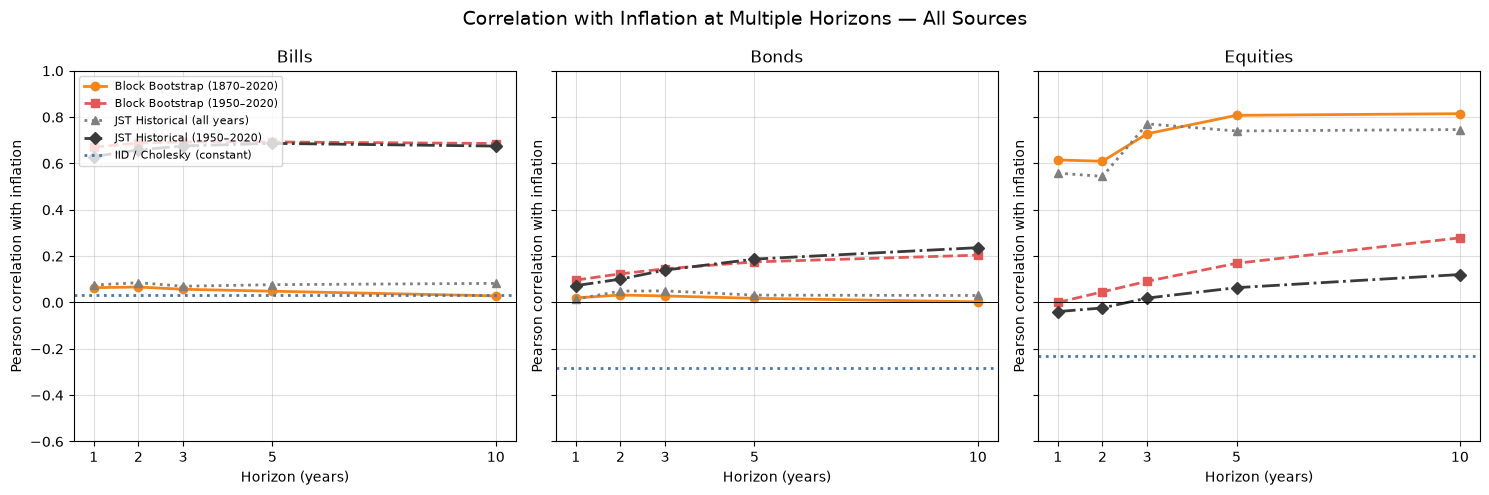

In [36]:
# Combined plot: all sources side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

all_corr_data = {
    'bb_1870':    corr_1870,
    'bb_1950':    corr_1950,
    'jst':        corr_jst,
    'jst_1950':   corr_jst_1950,
}
line_styles = {
    'bb_1870':  ('o-',  SAMPLER_COLORS['bb_1870'], 'Block Bootstrap (1870–2020)'),
    'bb_1950':  ('s--', SAMPLER_COLORS['bb_1950'], 'Block Bootstrap (1950–2020)'),
    'jst':      ('^:',  '#7f7f7f',                 'JST Historical (all years)'),
    'jst_1950': ('D-.', '#3a3a3a',                 'JST Historical (1950–2020)'),
}

for col, (ax, asset_idx, asset_name) in enumerate(
        zip(axes, range(3), ASSET_NAMES)):

    for key, (style, color, label) in line_styles.items():
        y = [all_corr_data[key][k][asset_idx] for k in HORIZONS]
        ax.plot(HORIZONS, y, style, color=color, label=label, lw=2, ms=6)

    # IID horizontal reference
    ax.axhline(iid_corr_with_cpi[asset_idx],
               color=SAMPLER_COLORS['iid'], lw=2, ls=':',
               label='IID / Cholesky (constant)')

    ax.axhline(0, color='black', lw=0.7)
    ax.set_xlabel('Horizon (years)')
    ax.set_ylabel('Pearson correlation with inflation')
    ax.set_title(asset_name)
    ax.set_xticks(HORIZONS)
    ax.set_ylim(-0.6, 1.0)
    ax.grid(alpha=0.4)
    if col == 0:
        ax.legend(fontsize=8, loc='upper left')

plt.suptitle('Correlation with Inflation at Multiple Horizons — All Sources',
             fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'where_are_bonds__inflation_corr_all.png', dpi=150,
            bbox_inches='tight')
plt.show()


---
## Section 5 — Variance Ratio Test (Mean Reversion)

The variance ratio $\text{VR}(k)$ measures whether multi-year returns scale faster or slower
than a random walk would predict:

$$\text{VR}(k) = \frac{\text{Var}(R_k)}{k \cdot \text{Var}(R_1)}$$

where $R_k$ is the $k$-year compounded return.

- $\text{VR}(k) = 1$: consistent with a random walk (IID returns)
- $\text{VR}(k) < 1$: **mean reversion** — variance grows slower than linearly; past losses tend to be recovered
- $\text{VR}(k) > 1$: **momentum** — variance grows faster than linearly; trends persist

For bonds, strong mean reversion would *help* explain their absence: the optimizer may
prefer equities if bond variance shrinks at longer horizons (lower risk premium per unit risk
at the horizons that matter for retirement).  Conversely, if bonds show momentum ($\text{VR}>1$)
their risk is understated by the 1-year volatility alone.

The IID/Cholesky sampler has $\text{VR}(k) \equiv 1$ by construction and is shown as a reference line.


In [14]:
def variance_ratios_from_npy(data, horizons):
    """
    Compute VR(k) = Var(k-year return) / (k * Var(1-year return)) for each asset.

    Parameters
    ----------
    data : ndarray, shape (n_scenarios, n_timesteps, n_assets+1)
        Last column is inflation (not included in output).
    horizons : list[int]

    Returns
    -------
    dict {horizon: ndarray (n_assets,)}
    """
    n_assets = data.shape[2] - 1

    # 1-year variance: pool all scenario-year observations
    flat_1yr = data[:, :, :n_assets].reshape(-1, n_assets)
    var_1yr  = flat_1yr.var(axis=0, ddof=1)   # (n_assets,)

    result = {}
    for k in horizons:
        windows = []
        for t in range(0, data.shape[1] - k + 1):
            compounded = np.prod(1.0 + data[:, t:t + k, :n_assets], axis=1) - 1.0
            windows.append(compounded)                        # (n_scenarios, n_assets)
        all_windows = np.concatenate(windows, axis=0)        # (N, n_assets)
        var_k = all_windows.var(axis=0, ddof=1)              # (n_assets,)
        result[k] = var_k / (k * var_1yr)
    return result


def variance_ratios_from_jst(df, horizons):
    """
    Compute VR(k) from the JST annual panel, pooling across countries.
    1-year variance is computed from the same pooled sample (all annual returns).
    """
    # 1-year variance: all country-year observations
    var_1yr = np.array([df[a].var(ddof=1) for a in ASSET_NAMES])

    result = {}
    for k in horizons:
        windows = {a: [] for a in ASSET_NAMES}
        for iso, grp in df.groupby('iso'):
            grp   = grp.sort_values('year').reset_index(drop=True)
            years = grp['year'].values
            n     = len(grp)
            for t in range(n - k + 1):
                if years[t + k - 1] - years[t] != k - 1:
                    continue
                for a in ASSET_NAMES:
                    ret_k = np.prod(1 + grp.loc[t:t + k - 1, a].values) - 1
                    windows[a].append(ret_k)

        var_k = np.array([np.var(windows[a], ddof=1) for a in ASSET_NAMES])
        result[k] = var_k / (k * var_1yr)
    return result


print("Computing variance ratios — Block Bootstrap 1870…")
vr_1870 = variance_ratios_from_npy(bb_1870_data, HORIZONS)
print("Computing variance ratios — Block Bootstrap 1950…")
vr_1950 = variance_ratios_from_npy(bb_1950_data, HORIZONS)
print("Computing variance ratios — JST full history…")
vr_jst  = variance_ratios_from_jst(jst, HORIZONS)
print("Computing variance ratios — JST 1950–2020…")
vr_jst_1950 = variance_ratios_from_jst(jst_1950, HORIZONS)
print("Done.")

for k in HORIZONS:
    print(f"  VR({k:2d}y) BB-1870:", dict(zip(ASSET_NAMES, np.round(vr_1870[k], 3))))


Computing variance ratios — Block Bootstrap 1870…
Computing variance ratios — Block Bootstrap 1950…
Computing variance ratios — JST full history…
Computing variance ratios — JST 1950–2020…
Done.
  VR( 1y) BB-1870: {'Bills': np.float64(1.0), 'Bonds': np.float64(1.0), 'Equities': np.float64(1.0)}
  VR( 2y) BB-1870: {'Bills': np.float64(2.078), 'Bonds': np.float64(1.155), 'Equities': np.float64(1.832)}
  VR( 3y) BB-1870: {'Bills': np.float64(3.295), 'Bonds': np.float64(1.474), 'Equities': np.float64(3.519)}
  VR( 5y) BB-1870: {'Bills': np.float64(6.224), 'Bonds': np.float64(2.156), 'Equities': np.float64(15.427)}
  VR(10y) BB-1870: {'Bills': np.float64(17.055), 'Bonds': np.float64(5.037), 'Equities': np.float64(178.566)}
  VR(15y) BB-1870: {'Bills': np.float64(34.006), 'Bonds': np.float64(10.125), 'Equities': np.float64(1154.378)}


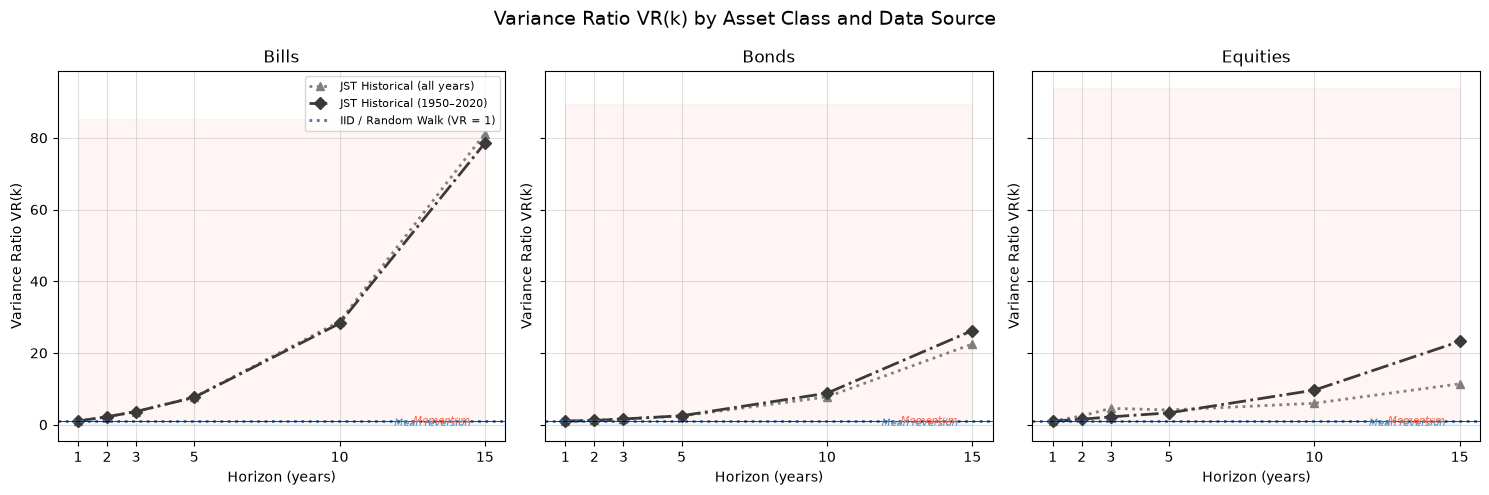

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

vr_sources = {
    # 'bb_1870':  (vr_1870,    'o-',  SAMPLER_COLORS['bb_1870'], 'Block Bootstrap (1870–2020)'),
    # 'bb_1950':  (vr_1950,    's--', SAMPLER_COLORS['bb_1950'], 'Block Bootstrap (1950–2020)'),
    'jst':      (vr_jst,     '^:',  '#7f7f7f',                 'JST Historical (all years)'),
    'jst_1950': (vr_jst_1950,'D-.', '#3a3a3a',                 'JST Historical (1950–2020)'),
}

for col, (ax, asset_idx, asset_name) in enumerate(
        zip(axes, range(3), ASSET_NAMES)):

    for key, (vr_dict, style, color, label) in vr_sources.items():
        y = [vr_dict[k][asset_idx] for k in HORIZONS]
        ax.plot(HORIZONS, y, style, color=color, label=label, lw=2, ms=6)

    # IID reference: VR = 1 at all horizons
    ax.axhline(1.0, color=SAMPLER_COLORS['iid'], lw=2, ls=':',
               label='IID / Random Walk (VR = 1)')

    ax.axhline(1.0, color='black', lw=0.5, ls='-')  # reinforce the baseline
    ax.set_xlabel('Horizon (years)')
    ax.set_ylabel('Variance Ratio VR(k)')
    ax.set_title(asset_name)
    ax.set_xticks(HORIZONS)
    ax.grid(alpha=0.4)
    if col == 0:
        ax.legend(fontsize=8, loc='upper right')

    # Annotate regions
    ax.fill_between([HORIZONS[0], HORIZONS[-1]], 0, 1,
                    color='steelblue', alpha=0.06, label='_nolegend_')
    ax.fill_between([HORIZONS[0], HORIZONS[-1]], 1, ax.get_ylim()[1] if ax.get_ylim()[1] > 1 else 2,
                    color='tomato', alpha=0.06, label='_nolegend_')
    ax.text(HORIZONS[-1] - 0.5, 0.5, 'Mean reversion', ha='right', va='center',
            fontsize=7, color='steelblue', style='italic')
    ax.text(HORIZONS[-1] - 0.5, 1.15, 'Momentum', ha='right', va='center',
            fontsize=7, color='tomato', style='italic')

plt.suptitle('Variance Ratio VR(k) by Asset Class and Data Source', fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'where_are_bonds__variance_ratio.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 6 — Autocorrelation of Annual Returns

Negative autocorrelation at lag $k$ means a good year tends to be followed by a below-average
year $k$ periods later — i.e. mean reversion.  Positive autocorrelation means momentum.
The IID/Cholesky sampler has zero autocorrelation at all lags by construction.

We compute the ACF two ways:

1. **Bootstrap data** — for each scenario path we compute the sample ACF across the $T$ timesteps,
   then average across all scenarios.  This recovers the serial dependence that the block-bootstrap
   procedure preserved from the historical data.

2. **JST historical panel** — for each country we compute the sample ACF, then take an
   equal-weighted average across countries.  This is the ground truth the bootstrap was built from.

Shaded bands show ±1.96 / √T (approximate 95% confidence interval for a white-noise series).


In [26]:
MAX_LAG = 10


def acf_1d(x, max_lag):
    """Sample ACF of a 1-D time series at lags 1..max_lag (lag-0 = 1 omitted)."""
    x = x - x.mean()
    n = len(x)
    var = np.dot(x, x) / n
    if var == 0:
        return np.zeros(max_lag)
    return np.array([np.dot(x[:n - k], x[k:]) / (n * var) for k in range(1, max_lag + 1)])


def acf_from_npy(data, max_lag):
    """
    Average ACF across all scenario paths.

    Parameters
    ----------
    data : ndarray, shape (n_scenarios, n_timesteps, n_cols)
    max_lag : int

    Returns
    -------
    ndarray, shape (n_cols - 1, max_lag)  — last column (CPI) excluded
    """
    n_scenarios, n_timesteps, n_cols = data.shape
    n_assets = n_cols - 1
    acf_sum = np.zeros((n_assets, max_lag))
    for s in range(n_scenarios):
        for j in range(n_assets):
            acf_sum[j] += acf_1d(data[s, :, j], max_lag)
    return acf_sum / n_scenarios   # (n_assets, max_lag)


def acf_from_jst(df, max_lag):
    """
    Average ACF across countries from the JST panel.

    Returns
    -------
    ndarray, shape (n_assets, max_lag)
    """
    acf_sum   = np.zeros((len(ASSET_NAMES), max_lag))
    n_counted = np.zeros((len(ASSET_NAMES), max_lag))

    for iso, grp in df.groupby('iso'):
        grp   = grp.sort_values('year').reset_index(drop=True)
        years = grp['year'].values

        # Split into contiguous segments (no year gaps)
        seg_start = [0]
        for i in range(1, len(years)):
            if years[i] - years[i - 1] > 1:
                seg_start.append(i)
        seg_start.append(len(years))

        for si in range(len(seg_start) - 1):
            seg = grp.iloc[seg_start[si]:seg_start[si + 1]]
            if len(seg) < max_lag + 2:
                continue
            for j, a in enumerate(ASSET_NAMES):
                acf_vals = acf_1d(seg[a].values, max_lag)
                acf_sum[j]   += acf_vals
                n_counted[j] += 1

    n_counted = np.where(n_counted == 0, 1, n_counted)
    return acf_sum / n_counted   # (n_assets, max_lag)


print("Computing ACF — Block Bootstrap 1870…")
acf_bb_1870 = acf_from_npy(bb_1870_data, MAX_LAG)
print("Computing ACF — Block Bootstrap 1950…")
acf_bb_1950 = acf_from_npy(bb_1950_data, MAX_LAG)
print("Computing ACF — JST full history…")
acf_jst     = acf_from_jst(jst, MAX_LAG)
print("Computing ACF — JST 1950–2020…")
acf_jst_1950 = acf_from_jst(jst_1950, MAX_LAG)
print("Done.")


Computing ACF — Block Bootstrap 1870…
Computing ACF — Block Bootstrap 1950…
Computing ACF — JST full history…
Computing ACF — JST 1950–2020…
Done.


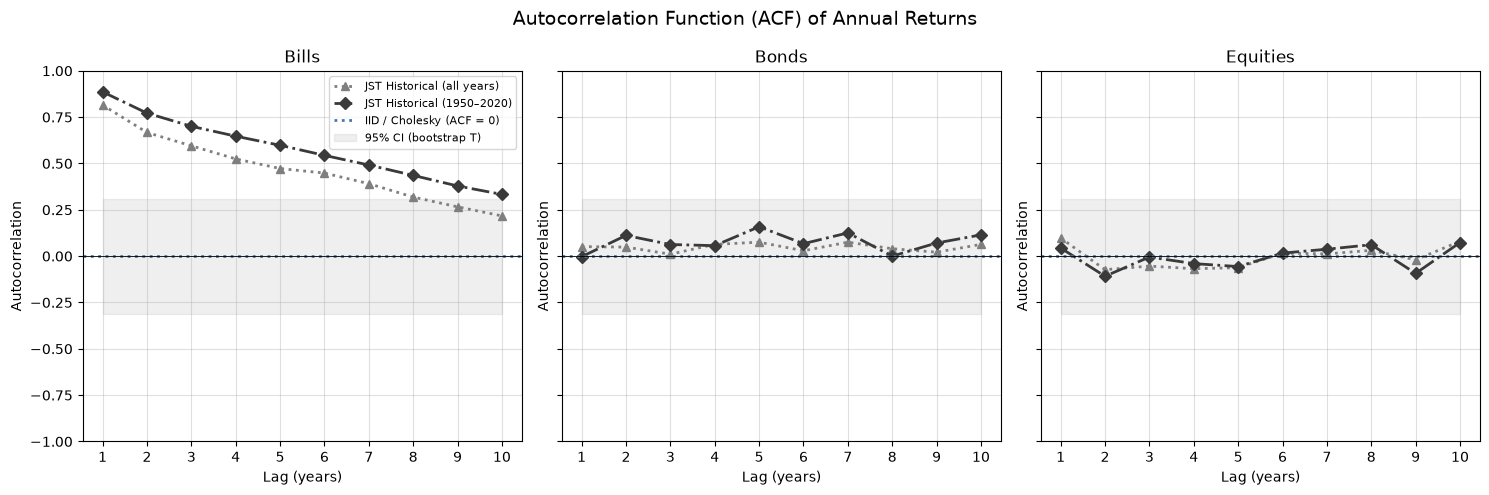

In [29]:
lags = np.arange(1, MAX_LAG + 1)

# 95% CI bound for white noise: ±1.96/sqrt(T)
# Use effective T from the bootstrap timestep count
T_bb   = bb_1870_data.shape[1]
T_jst  = jst.groupby('iso').size().median()   # median country series length
ci_bb  = 1.96 / np.sqrt(T_bb)
ci_jst = 1.96 / np.sqrt(T_jst)

acf_sources = {
    # 'bb_1870':  (acf_bb_1870,  'o-',  SAMPLER_COLORS['bb_1870'], 'Block Bootstrap (1870–2020)', ci_bb),
    # 'bb_1950':  (acf_bb_1950,  's--', SAMPLER_COLORS['bb_1950'], 'Block Bootstrap (1950–2020)', ci_bb),
    'jst':      (acf_jst,      '^:',  '#7f7f7f',                 'JST Historical (all years)',  ci_jst),
    'jst_1950': (acf_jst_1950, 'D-.', '#3a3a3a',                 'JST Historical (1950–2020)',  ci_jst),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for col, (ax, asset_idx, asset_name) in enumerate(
        zip(axes, range(3), ASSET_NAMES)):

    for key, (acf_mat, style, color, label, ci) in acf_sources.items():
        ax.plot(lags, acf_mat[asset_idx], style, color=color, label=label, lw=2, ms=6)

    # IID reference: ACF = 0 at all lags
    ax.axhline(0, color=SAMPLER_COLORS['iid'], lw=2, ls=':',
               label='IID / Cholesky (ACF = 0)')

    # 95% CI band for white noise (approximate; shown for bootstrap T)
    ax.fill_between(lags, -ci_bb, ci_bb,
                    color='grey', alpha=0.12, label='95% CI (bootstrap T)')

    ax.axhline(0, color='black', lw=0.6)
    ax.set_xlabel('Lag (years)')
    ax.set_ylabel('Autocorrelation')
    ax.set_title(asset_name)
    ax.set_xticks(lags)
    ax.set_ylim(-1, 1)
    ax.grid(alpha=0.4)
    if col == 0:
        ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Autocorrelation Function (ACF) of Annual Returns', fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'where_are_bonds__acf.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 7 — Partial Autocorrelation Function (PACF)

The PACF at lag $k$ is the correlation between $r_t$ and $r_{t+k}$ **after removing the
linear influence of all intermediate lags** $1, \ldots, k-1$.

- ACF aggregates direct *and* indirect effects; PACF isolates the direct effect at each lag.
- A significant PACF at lag 1 only (with near-zero values thereafter) implies an AR(1) process.
- Persistent significant PACF values suggest higher-order AR dynamics or regime clustering.

Computed via the Levinson-Durbin recursion applied to the ACF estimates from Section 6.


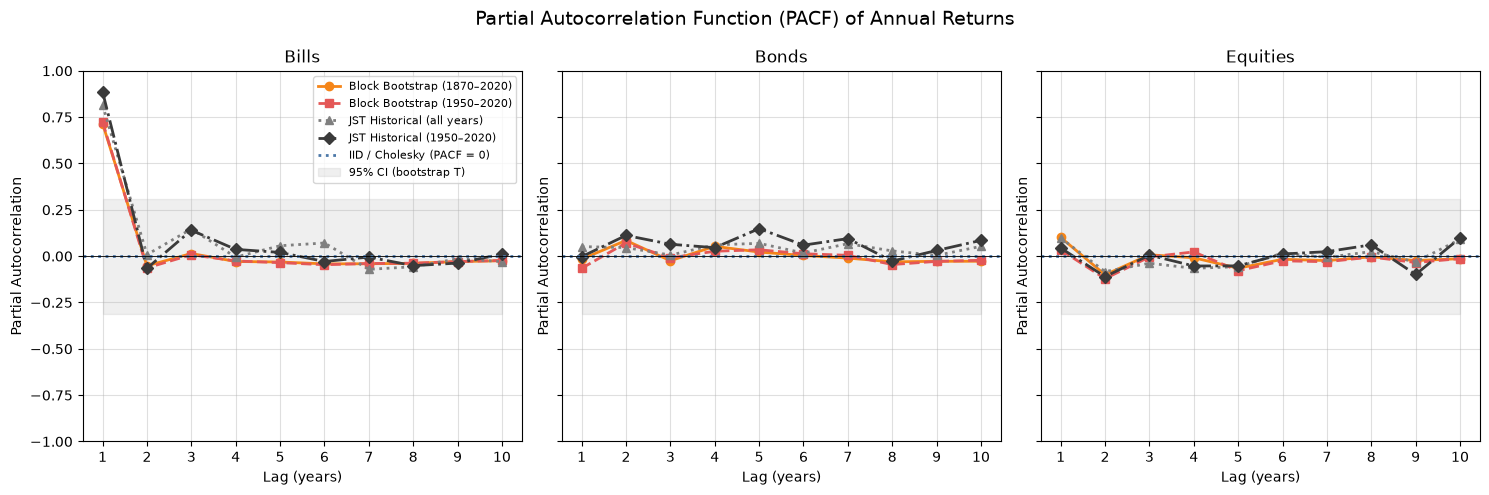

In [31]:
def acf_to_pacf(acf_vals):
    """
    Convert ACF values (lags 1..K) to PACF via the Levinson-Durbin recursion.

    Parameters
    ----------
    acf_vals : array-like, length K
        ACF at lags 1, 2, ..., K  (lag-0 = 1 is NOT included).

    Returns
    -------
    pacf : ndarray, length K
        PACF at lags 1, 2, ..., K.
    """
    rho  = np.asarray(acf_vals)
    K    = len(rho)
    pacf = np.zeros(K)
    phi  = np.zeros(K)          # current AR coefficients

    for k in range(K):
        order = k + 1           # lag being estimated
        if order == 1:
            phi_new = rho[0]
        else:
            num   = rho[k] - np.dot(phi[:k], rho[k - 1::-1])
            denom = 1.0  - np.dot(phi[:k], rho[:k])
            phi_new = num / denom if abs(denom) > 1e-12 else 0.0
            phi[:k] = phi[:k] - phi_new * phi[:k][::-1]
        phi[k]   = phi_new
        pacf[k]  = phi_new

    return pacf


# Compute PACF from the ACF matrices already in memory
# acf_*  shape: (n_assets, MAX_LAG)
pacf_bb_1870  = np.array([acf_to_pacf(acf_bb_1870[j])  for j in range(len(ASSET_NAMES))])
pacf_bb_1950  = np.array([acf_to_pacf(acf_bb_1950[j])  for j in range(len(ASSET_NAMES))])
pacf_jst      = np.array([acf_to_pacf(acf_jst[j])      for j in range(len(ASSET_NAMES))])
pacf_jst_1950 = np.array([acf_to_pacf(acf_jst_1950[j]) for j in range(len(ASSET_NAMES))])

pacf_sources = {
    'bb_1870':  (pacf_bb_1870,  'o-',  SAMPLER_COLORS['bb_1870'], 'Block Bootstrap (1870–2020)'),
    'bb_1950':  (pacf_bb_1950,  's--', SAMPLER_COLORS['bb_1950'], 'Block Bootstrap (1950–2020)'),
    'jst':      (pacf_jst,      '^:',  '#7f7f7f',                 'JST Historical (all years)'),
    'jst_1950': (pacf_jst_1950, 'D-.', '#3a3a3a',                 'JST Historical (1950–2020)'),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for col, (ax, asset_idx, asset_name) in enumerate(
        zip(axes, range(3), ASSET_NAMES)):

    for key, (pacf_mat, style, color, label) in pacf_sources.items():
        ax.plot(lags, pacf_mat[asset_idx], style, color=color, label=label, lw=2, ms=6)

    ax.axhline(0, color=SAMPLER_COLORS['iid'], lw=2, ls=':',
               label='IID / Cholesky (PACF = 0)')
    ax.fill_between(lags, -ci_bb, ci_bb,
                    color='grey', alpha=0.12, label='95% CI (bootstrap T)')

    ax.axhline(0, color='black', lw=0.6)
    ax.set_xlabel('Lag (years)')
    ax.set_ylabel('Partial Autocorrelation')
    ax.set_title(asset_name)
    ax.set_xticks(lags)
    ax.set_ylim(-1, 1)
    ax.grid(alpha=0.4)
    if col == 0:
        ax.legend(fontsize=8, loc='upper right')

plt.suptitle('Partial Autocorrelation Function (PACF) of Annual Returns', fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'where_are_bonds__pacf.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 8 — ACF and PACF of Real Returns

Sections 6 and 7 used *nominal* returns.  Because inflation is itself serially correlated,
some of the autocorrelation structure in nominal bonds may simply reflect shared exposure to
inflationary regimes rather than any mean-reversion in real wealth.

Here we deflate each annual return by the contemporaneous CPI:

$$r^{\text{real}}_t = \frac{1 + r^{\text{nom}}_t}{1 + \pi_t} - 1$$

and re-compute ACF and PACF on the real series.  Comparing with Sections 6 and 7 reveals how
much of the serial structure is inflation-driven vs intrinsic to the asset class.


ACF of real returns — Block Bootstrap 1870…
ACF of real returns — Block Bootstrap 1950…
ACF of real returns — JST full history…
ACF of real returns — JST 1950–2020…
Done.


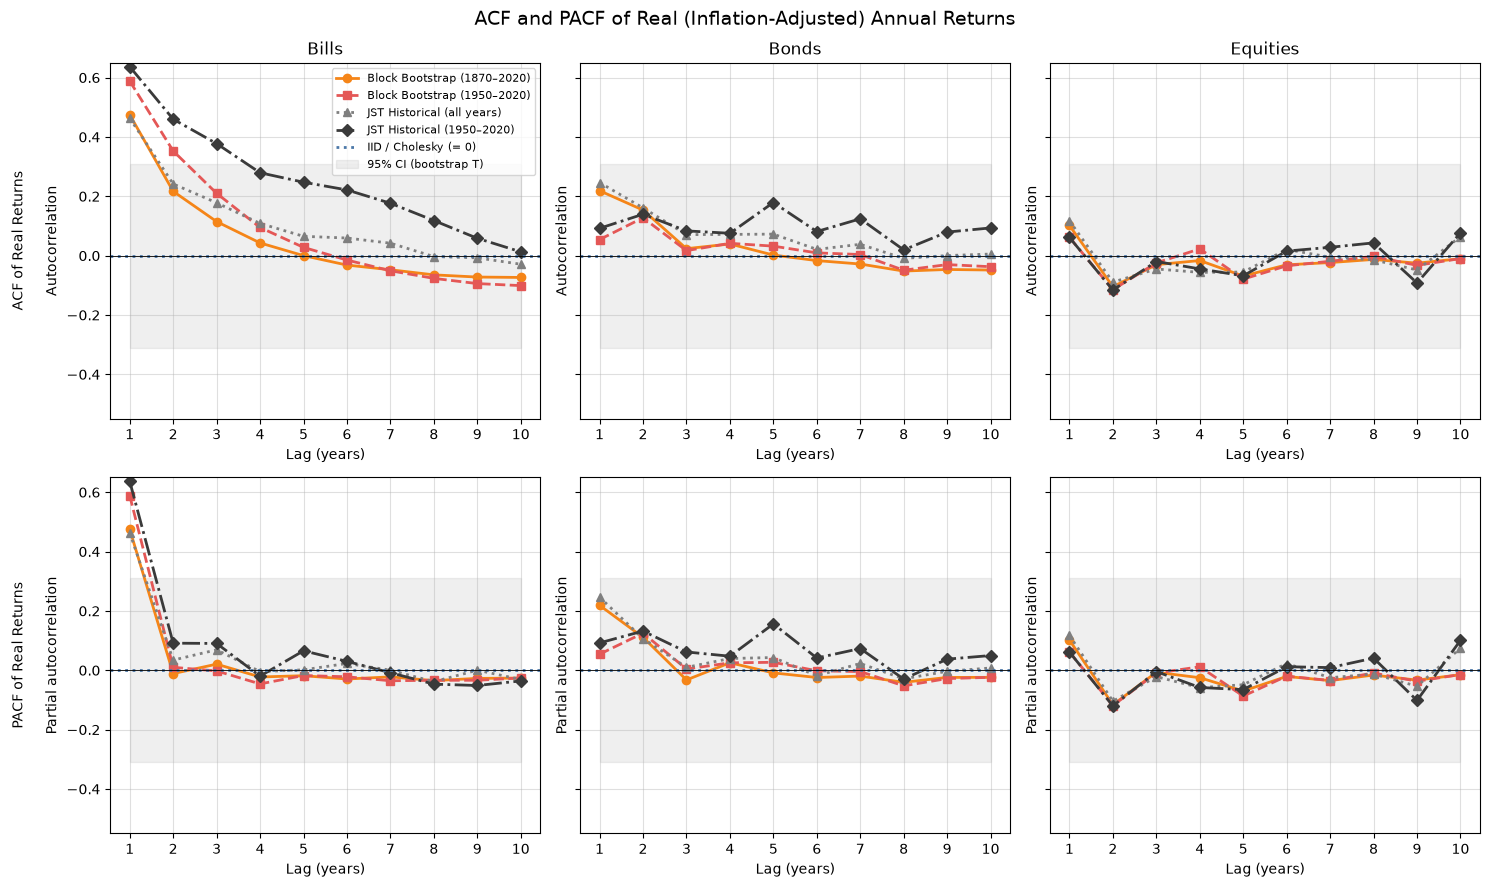

In [32]:
# --- Build real-return versions of each dataset ----------------------------

def deflate_npy(data):
    """
    Replace nominal asset columns with real returns (deflated by contemporaneous CPI).
    Returns an array of the same shape; last column is kept as CPI (unchanged).
    """
    out = data.copy()
    cpi = data[:, :, -1]                               # (n_scenarios, n_timesteps)
    for j in range(data.shape[2] - 1):
        out[:, :, j] = (1 + data[:, :, j]) / (1 + cpi) - 1
    return out


def deflate_jst(df):
    """Return a copy of df with Bills/Bonds/Equities replaced by real returns."""
    df2 = df.copy()
    for a in ASSET_NAMES:
        df2[a] = (1 + df[a]) / (1 + df['CPI']) - 1
    return df2


bb_1870_real = deflate_npy(bb_1870_data)
bb_1950_real = deflate_npy(bb_1950_data)
jst_real      = deflate_jst(jst)
jst_1950_real = deflate_jst(jst_1950)

# --- ACF of real returns ---------------------------------------------------
print("ACF of real returns — Block Bootstrap 1870…")
acf_real_bb_1870  = acf_from_npy(bb_1870_real,  MAX_LAG)
print("ACF of real returns — Block Bootstrap 1950…")
acf_real_bb_1950  = acf_from_npy(bb_1950_real,  MAX_LAG)
print("ACF of real returns — JST full history…")
acf_real_jst      = acf_from_jst(jst_real,       MAX_LAG)
print("ACF of real returns — JST 1950–2020…")
acf_real_jst_1950 = acf_from_jst(jst_1950_real,  MAX_LAG)

# --- PACF of real returns (via Levinson-Durbin on ACF) --------------------
pacf_real_bb_1870  = np.array([acf_to_pacf(acf_real_bb_1870[j])  for j in range(len(ASSET_NAMES))])
pacf_real_bb_1950  = np.array([acf_to_pacf(acf_real_bb_1950[j])  for j in range(len(ASSET_NAMES))])
pacf_real_jst      = np.array([acf_to_pacf(acf_real_jst[j])      for j in range(len(ASSET_NAMES))])
pacf_real_jst_1950 = np.array([acf_to_pacf(acf_real_jst_1950[j]) for j in range(len(ASSET_NAMES))])
print("Done.")

# --- Plot: 2 rows (ACF / PACF) × 3 cols (Bills / Bonds / Equities) --------
acf_real_sources = {
    'bb_1870':  (acf_real_bb_1870,  pacf_real_bb_1870,  'o-',  SAMPLER_COLORS['bb_1870'], 'Block Bootstrap (1870–2020)'),
    'bb_1950':  (acf_real_bb_1950,  pacf_real_bb_1950,  's--', SAMPLER_COLORS['bb_1950'], 'Block Bootstrap (1950–2020)'),
    'jst':      (acf_real_jst,      pacf_real_jst,      '^:',  '#7f7f7f',                 'JST Historical (all years)'),
    'jst_1950': (acf_real_jst_1950, pacf_real_jst_1950, 'D-.', '#3a3a3a',                 'JST Historical (1950–2020)'),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey='row')
row_labels = ['ACF of Real Returns', 'PACF of Real Returns']

for row, func_idx in enumerate([0, 1]):   # 0 = ACF array, 1 = PACF array
    for col, (asset_idx, asset_name) in enumerate(zip(range(3), ASSET_NAMES)):
        ax = axes[row, col]

        for key, (acf_arr, pacf_arr, style, color, label) in acf_real_sources.items():
            vals = acf_arr[asset_idx] if func_idx == 0 else pacf_arr[asset_idx]
            ax.plot(lags, vals, style, color=color, label=label, lw=2, ms=6)

        ax.axhline(0, color=SAMPLER_COLORS['iid'], lw=2, ls=':',
                   label='IID / Cholesky (= 0)')
        ax.fill_between(lags, -ci_bb, ci_bb, color='grey', alpha=0.12,
                        label='95% CI (bootstrap T)')
        ax.axhline(0, color='black', lw=0.6)

        ax.set_xlabel('Lag (years)')
        ax.set_ylabel('Partial autocorrelation' if func_idx == 1 else 'Autocorrelation')
        ax.set_xticks(lags)
        ax.set_ylim(-0.55, 0.65)
        ax.grid(alpha=0.4)

        if row == 0:
            ax.set_title(asset_name, fontsize=12)
        if row == 0 and col == 0:
            ax.legend(fontsize=8, loc='upper right')

    # Row label on the left
    axes[row, 0].set_ylabel(f'{row_labels[row]}\n\nAutocorrelation' if func_idx == 0
                            else f'{row_labels[row]}\n\nPartial autocorrelation')

plt.suptitle('ACF and PACF of Real (Inflation-Adjusted) Annual Returns', fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'where_are_bonds__real_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 9 — Variance Ratio of Real Returns

Repeats the VR analysis from Section 5 on inflation-deflated returns.
Comparing the two reveals how much of the nominal mean-reversion / momentum signal is
driven by inflation regimes vs intrinsic asset price dynamics.


Computing VR — real returns…
Done.


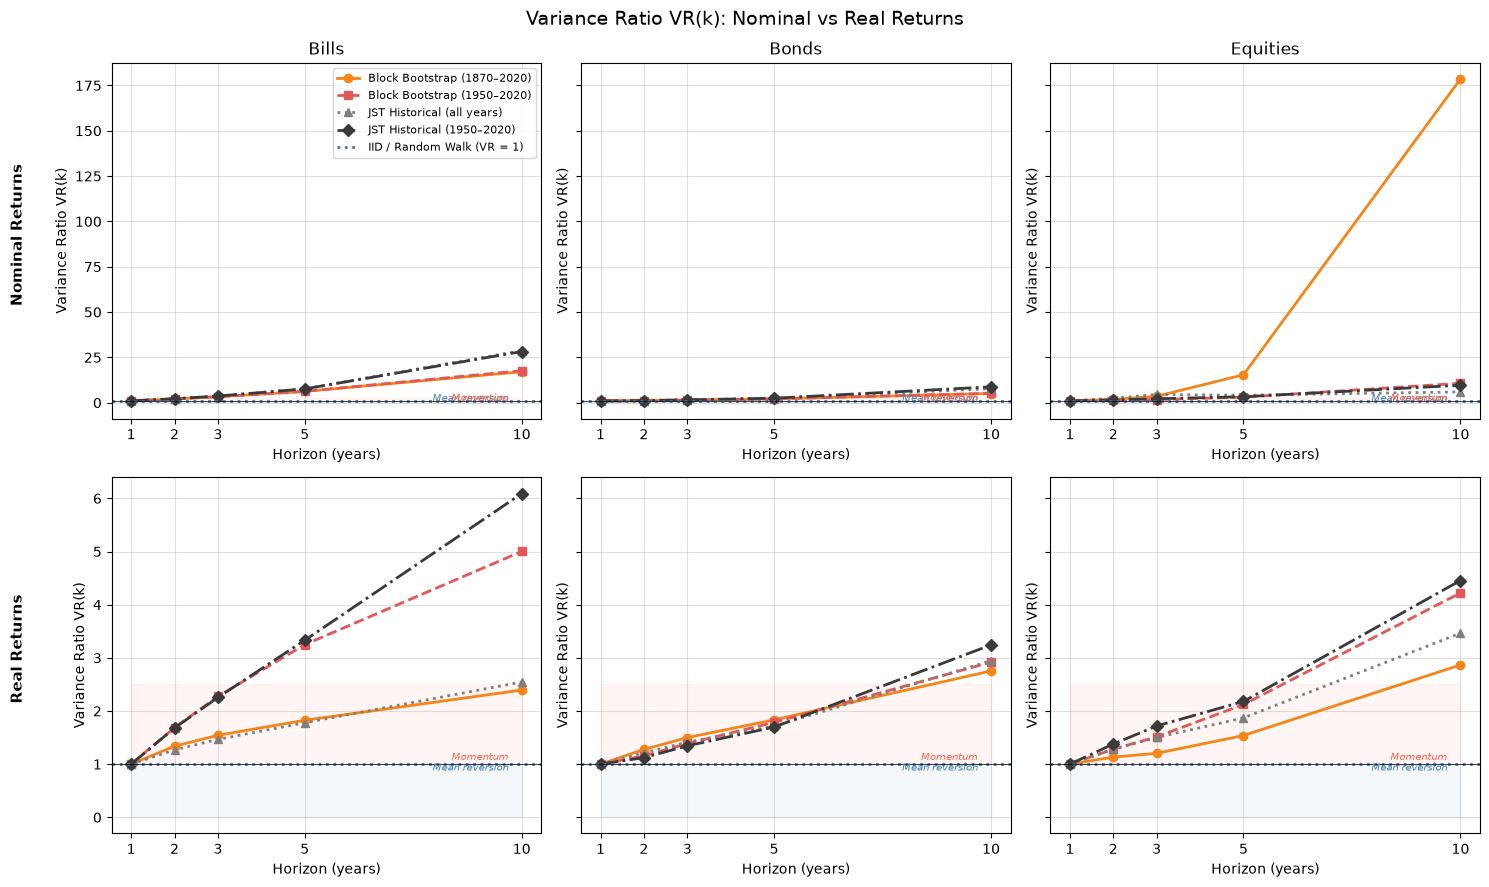

In [33]:
print("Computing VR — real returns…")
vr_real_1870     = variance_ratios_from_npy(bb_1870_real,  HORIZONS)
vr_real_1950     = variance_ratios_from_npy(bb_1950_real,  HORIZONS)
vr_real_jst      = variance_ratios_from_jst(jst_real,      HORIZONS)
vr_real_jst_1950 = variance_ratios_from_jst(jst_1950_real, HORIZONS)
print("Done.")

# --- Side-by-side: nominal VR (left col) vs real VR (right col) -----------
fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey='row')

vr_nom_sources = {
    'bb_1870':  (vr_1870,     'o-',  SAMPLER_COLORS['bb_1870'], 'Block Bootstrap (1870–2020)'),
    'bb_1950':  (vr_1950,     's--', SAMPLER_COLORS['bb_1950'], 'Block Bootstrap (1950–2020)'),
    'jst':      (vr_jst,      '^:',  '#7f7f7f',                 'JST Historical (all years)'),
    'jst_1950': (vr_jst_1950, 'D-.', '#3a3a3a',                 'JST Historical (1950–2020)'),
}
vr_real_sources = {
    'bb_1870':  (vr_real_1870,     'o-',  SAMPLER_COLORS['bb_1870'], 'Block Bootstrap (1870–2020)'),
    'bb_1950':  (vr_real_1950,     's--', SAMPLER_COLORS['bb_1950'], 'Block Bootstrap (1950–2020)'),
    'jst':      (vr_real_jst,      '^:',  '#7f7f7f',                 'JST Historical (all years)'),
    'jst_1950': (vr_real_jst_1950, 'D-.', '#3a3a3a',                 'JST Historical (1950–2020)'),
}

row_data   = [vr_nom_sources,  vr_real_sources]
row_titles = ['Nominal Returns', 'Real Returns']

for row, (sources, row_title) in enumerate(zip(row_data, row_titles)):
    for col, (asset_idx, asset_name) in enumerate(zip(range(3), ASSET_NAMES)):
        ax = axes[row, col]

        for key, (vr_dict, style, color, label) in sources.items():
            y = [vr_dict[k][asset_idx] for k in HORIZONS]
            ax.plot(HORIZONS, y, style, color=color, label=label, lw=2, ms=6)

        ax.axhline(1.0, color=SAMPLER_COLORS['iid'], lw=2, ls=':',
                   label='IID / Random Walk (VR = 1)')
        ax.axhline(1.0, color='black', lw=0.5)
        ax.fill_between(HORIZONS, 0, 1,   color='steelblue', alpha=0.06)
        ax.fill_between(HORIZONS, 1, 2.5, color='tomato',    alpha=0.06)
        ax.text(HORIZONS[-1] - 0.3, 0.88, 'Mean reversion', ha='right',
                fontsize=7, color='steelblue', style='italic')
        ax.text(HORIZONS[-1] - 0.3, 1.08, 'Momentum',       ha='right',
                fontsize=7, color='tomato',    style='italic')

        ax.set_xlabel('Horizon (years)')
        ax.set_ylabel('Variance Ratio VR(k)')
        ax.set_xticks(HORIZONS)
        ax.grid(alpha=0.4)

        if row == 0:
            ax.set_title(asset_name, fontsize=12)
        if row == 0 and col == 0:
            ax.legend(fontsize=8, loc='upper right')

    axes[row, 0].set_title(f'{row_titles[row]} — {ASSET_NAMES[0]}', fontsize=11)

# Fix column titles for row 1 (overwrite after loop)
for col, asset_name in enumerate(ASSET_NAMES):
    axes[0, col].set_title(asset_name, fontsize=12)
    axes[1, col].set_title('')

fig.text(0.01, 0.73, 'Nominal Returns', va='center', rotation='vertical',
         fontsize=11, fontweight='bold')
fig.text(0.01, 0.27, 'Real Returns', va='center', rotation='vertical',
         fontsize=11, fontweight='bold')

plt.suptitle('Variance Ratio VR(k): Nominal vs Real Returns', fontsize=14)
plt.tight_layout(rect=[0.03, 0, 1, 1])
plt.savefig(PLOTS_DIR / 'where_are_bonds__vr_real_vs_nominal.png', dpi=150,
            bbox_inches='tight')
plt.show()


---
## Section 10 — The Actual Answer: Scenario-Level Outcome Distributions

The analyses so far look at 1-year statistics (means, ACF, VR).  But the optimizer faces a
**40-year retirement path** and minimises something like bankruptcy probability.  The right
question is therefore: *across full bootstrap scenarios, what does the 40-year compounded real
return distribution look like for each asset?*

### Two notes on methodology

**VR artefact (Sections 5 & 9).**  The block bootstrap data has shape
`(n_scenarios, 40, 4)` where each scenario is an *independent draw* of a complete
historical 40-year path.  When we pool overlapping windows *across scenarios* to compute
$k$-year variance, between-scenario variance (different regimes, different inflation epochs)
dominates completely.  This makes $\text{VR}(k) \gg 1$ for all assets at long horizons —
a computational artefact, not evidence of momentum.  The VR plots should be read with
caution for bootstrap data.

**Inflation heterogeneity.**  The bootstrap CPI annual std is ~34% for the 1870-based
data (vs 1.6% in the IID model).  This is again the between-scenario inflation uncertainty:
some scenarios are drawn from hyperinflationary decades, others from low-inflation periods.
The IID model has no concept of persistent inflationary regimes — every year is drawn
independently — so it severely underestimates the probability of a bad inflation path.


In [46]:
# ---------------------------------------------------------------------------
# Full-path (40-year) compounded real returns per scenario
# ---------------------------------------------------------------------------

def scenario_real_returns(data, max_horizon=40):
    """
    max_horizon-year compounded real return for each scenario.
    Returns array of shape (n_scenarios, n_assets).
    """
    cum_nom = np.prod(1.0 + data[:, :max_horizon, :-1], axis=1)   # (n_scenarios, n_assets)
    cum_inf = np.prod(1.0 + data[:, :max_horizon, -1],  axis=1)   # (n_scenarios,)
    return cum_nom / cum_inf[:, None] - 1.0
horizon = 35

print(f"Computing scenario-level {horizon}yr real returns…")
sr_1870 = scenario_real_returns(bb_1870_data, max_horizon=horizon)   # (469217, 3)
sr_1950 = scenario_real_returns(bb_1950_data, max_horizon=horizon)   # (463912, 3)
print("Done.")

# --- Summary statistics ---------------------------------------------------
pctiles = [5, 25, 50, 75, 95]
header  = f"{'Asset':<10} {'p5':>8} {'p25':>8} {'p50':>8} {'p75':>8} {'p95':>8}  {'P(<0)':>7} {'P(<Bills)':>10}"

for label, sr in [('BB 1870', sr_1870), ('BB 1950', sr_1950)]:
    print(f"\n── {label} — {horizon}yr compounded real returns ──")
    print(header)
    for j, a in enumerate(ASSET_NAMES):
        pts = np.percentile(sr[:, j], pctiles) * 100
        p_neg  = (sr[:, j] < 0).mean()
        p_lt_bills = (sr[:, j] < sr[:, 0]).mean() if j > 0 else float('nan')
        print(f"{a:<10} {pts[0]:>7.1f}% {pts[1]:>7.1f}% {pts[2]:>7.1f}% "
              f"{pts[3]:>7.1f}% {pts[4]:>7.1f}%  {p_neg:>7.1%} {p_lt_bills:>10.1%}")


Computing scenario-level 35yr real returns…
Done.

── BB 1870 — 35yr compounded real returns ──
Asset            p5      p25      p50      p75      p95    P(<0)  P(<Bills)
Bills        -89.0%   -16.8%    39.4%   109.0%   253.5%    32.0%       nan%
Bonds        -86.6%    -5.0%    91.3%   233.4%   559.7%    26.3%      24.2%
Equities      60.3%   341.7%   708.6%  1317.5%  2946.9%     2.2%       0.6%

── BB 1950 — 35yr compounded real returns ──
Asset            p5      p25      p50      p75      p95    P(<0)  P(<Bills)
Bills        -33.6%     2.6%    34.9%    78.1%   167.7%    23.0%       nan%
Bonds        -37.4%    37.3%   123.6%   251.4%   514.0%    13.9%      19.6%
Equities     108.8%   413.9%   853.4%  1625.6%  3681.6%     0.7%       0.5%


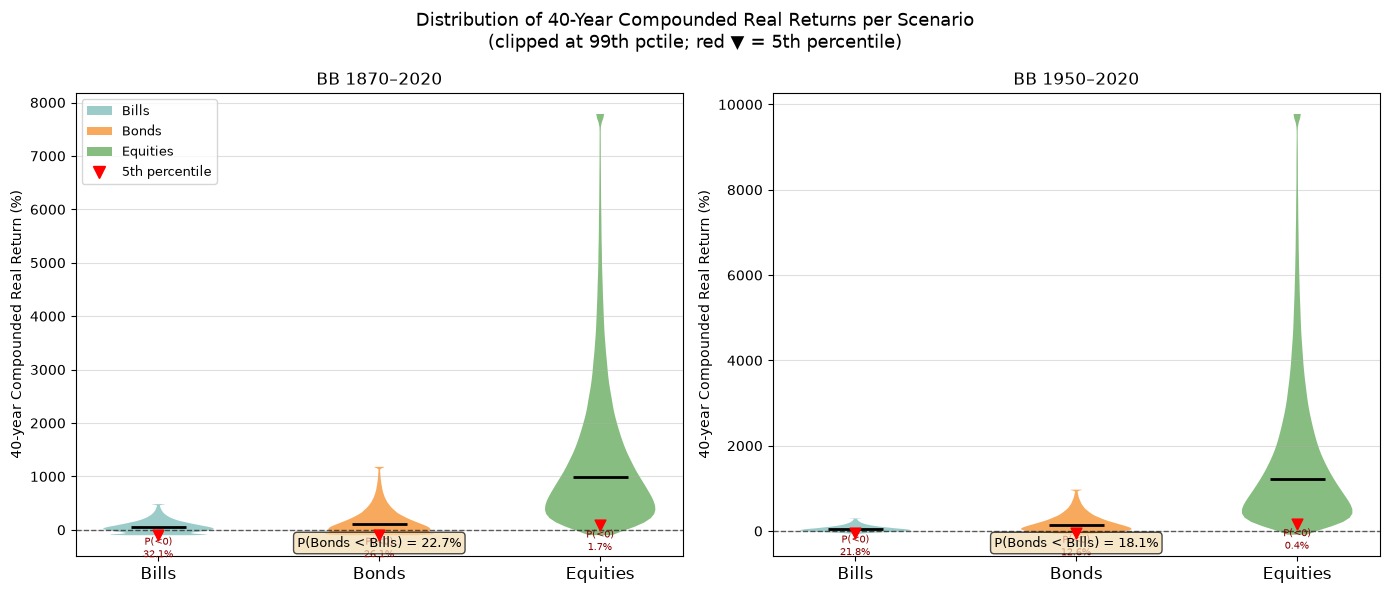

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (label, sr) in zip(axes, [('BB 1870–2020', sr_1870), ('BB 1950–2020', sr_1950)]):

    # Clip extreme outliers for visualisation (99th pctile cap)
    cap = np.percentile(sr, 99, axis=0)
    sr_clipped = np.clip(sr, -1, cap)

    parts = ax.violinplot(
        [sr_clipped[:, j] * 100 for j in range(3)],
        positions=range(3), showmedians=True, showextrema=False,
    )
    for pc, color in zip(parts['bodies'],
                         [ASSET_COLORS['Bills'], ASSET_COLORS['Bonds'],
                          ASSET_COLORS['Equities']]):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)

    # Add p5 markers
    for j in range(3):
        p5 = np.percentile(sr[:, j], 5) * 100
        ax.scatter(j, p5, marker='v', color='red', s=60, zorder=5,
                   label='5th pctile' if j == 0 else '_nolegend_')

    # Reference line at 0
    ax.axhline(0, color='black', lw=1, ls='--', alpha=0.6)

    ax.set_xticks(range(3))
    ax.set_xticklabels(ASSET_NAMES, fontsize=12)
    ax.set_ylabel('40-year Compounded Real Return (%)')
    ax.set_title(label, fontsize=12)
    ax.grid(axis='y', alpha=0.4)

    # Annotate P(< 0) and P(bonds < bills) on the plot
    for j, a in enumerate(ASSET_NAMES):
        p_neg = (sr[:, j] < 0).mean()
        ax.text(j, np.percentile(sr[:, j], 3) * 100 - 15,
                f'P(<0)\n{p_neg:.1%}',
                ha='center', va='top', fontsize=7.5, color='darkred')

    # Add P(bonds < bills) annotation
    p_b_lt_bills = (sr[:, 1] < sr[:, 0]).mean()
    ax.text(0.5, 0.02, f'P(Bonds < Bills) = {p_b_lt_bills:.1%}',
            transform=ax.transAxes, ha='center', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.7))

handles = [
    plt.matplotlib.patches.Patch(facecolor=ASSET_COLORS[a], alpha=0.7, label=a)
    for a in ASSET_NAMES
] + [plt.Line2D([0], [0], marker='v', color='red', linestyle='none',
                markersize=8, label='5th percentile')]
axes[0].legend(handles=handles, fontsize=9, loc='upper left')

plt.suptitle('Distribution of 40-Year Compounded Real Returns per Scenario\n'
             '(clipped at 99th pctile; red ▼ = 5th percentile)',
             fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'where_are_bonds__scenario_distributions.png', dpi=150,
            bbox_inches='tight')
plt.show()


---
## Section 11 — ACF and PACF of Inflation (CPI)

The key mechanism behind bond losses is **persistent inflation**.  If inflation were IID,
a bad inflation year would not predict the next — bonds would merely suffer a one-off loss.
But if inflation is strongly autocorrelated (as historical data suggests), an inflationary
episode persists for years, systematically eroding the real value of fixed-coupon bonds
over the very multi-year windows the optimizer cares about.

The IID model has zero CPI autocorrelation by construction — this is the root cause of
why it treats bonds much more favourably than the bootstrap.


In [40]:
pip install statsmodels

  Using cached scipy-1.18.0-cp314-cp314-win_amd64.whl.metadata (61 kB)
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   --------------------------- ------------ 6.6/9.6 MB 42.5 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 32.7 MB/s  0:00:00
Using cached scipy-1.18.0-cp314-cp314-win_amd64.whl (37.3 MB)

   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------------------- 0/3 [scipy]
   ---------------------------


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Computing CPI ACF…
Done.


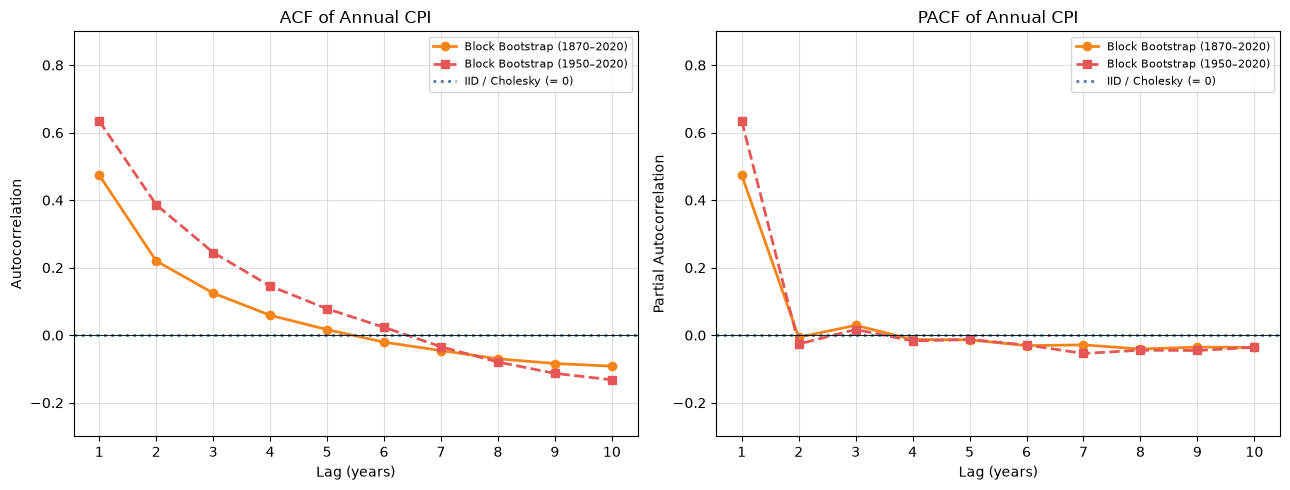


CPI ACF at lag 1 (regime persistence measure):
  bb_1870     : 0.474
  bb_1950     : 0.634


In [49]:
def acf_cpi_from_npy(data, max_lag):
    """
    Vectorised average ACF of the CPI column across all scenario paths.
    data : (n_scenarios, n_timesteps, n_cols) — last column is CPI.
    """
    cpi  = data[:, :, -1].astype(float)          # (n_scenarios, T) 
    mu   = cpi.mean(axis=1, keepdims=True)
    x    = cpi - mu                               # demeaned
    var  = (x ** 2).mean(axis=1)                  # (n_scenarios,)
    T    = cpi.shape[1]
    acf  = np.array([
        ((x[:, :T - k] * x[:, k:]).mean(axis=1) / np.where(var > 0, var, np.nan)).mean()
        for k in range(1, max_lag + 1)
    ])
    return acf   # (max_lag,)


def acf_cpi_from_jst(df, max_lag):
    """Average ACF of annual CPI across contiguous country segments."""
    acf_sum   = np.zeros(max_lag)
    n_counted = 0

    for iso, grp in df.groupby('iso'):
        grp   = grp.sort_values('year').reset_index(drop=True)
        years = grp['year'].values

        seg_start = [0]
        for i in range(1, len(years)):
            if years[i] - years[i - 1] > 1:
                seg_start.append(i)
        seg_start.append(len(years))

        for si in range(len(seg_start) - 1):
            seg = grp.iloc[seg_start[si]:seg_start[si + 1]]
            if len(seg) < max_lag + 2:
                continue
            acf_sum   += acf_1d(seg['CPI'].values, max_lag)
            n_counted += 1

    return acf_sum / max(n_counted, 1)


print("Computing CPI ACF…")
acf_cpi_1870     = acf_cpi_from_npy(bb_1870_data, MAX_LAG)
acf_cpi_1950     = acf_cpi_from_npy(bb_1950_data, MAX_LAG)
acf_cpi_jst      = acf_cpi_from_jst(jst,      MAX_LAG)
acf_cpi_jst_1950 = acf_cpi_from_jst(jst_1950, MAX_LAG)
print("Done.")

pacf_cpi_1870     = acf_to_pacf(acf_cpi_1870)
pacf_cpi_1950     = acf_to_pacf(acf_cpi_1950)
pacf_cpi_jst      = acf_to_pacf(acf_cpi_jst)
pacf_cpi_jst_1950 = acf_to_pacf(acf_cpi_jst_1950)

cpi_sources = {
    'bb_1870':  (acf_cpi_1870,  pacf_cpi_1870,  'o-',  SAMPLER_COLORS['bb_1870'], 'Block Bootstrap (1870–2020)'),
    'bb_1950':  (acf_cpi_1950,  pacf_cpi_1950,  's--', SAMPLER_COLORS['bb_1950'], 'Block Bootstrap (1950–2020)'),
    # 'jst':      (acf_cpi_jst,   pacf_cpi_jst,   '^:',  '#7f7f7f',                 'JST Historical (all years)'),
    # 'jst_1950': (acf_cpi_jst_1950, pacf_cpi_jst_1950, 'D-.', '#3a3a3a',           'JST Historical (1950–2020)'),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, func_idx, ylabel, title in [
    (axes[0], 0, 'Autocorrelation',         'ACF of Annual CPI'),
    (axes[1], 1, 'Partial Autocorrelation',  'PACF of Annual CPI'),
]:
    for key, (acf_arr, pacf_arr, style, color, label) in cpi_sources.items():
        vals = acf_arr if func_idx == 0 else pacf_arr
        ax.plot(lags, vals, style, color=color, label=label, lw=2, ms=6)

    ax.axhline(0, color=SAMPLER_COLORS['iid'], lw=2, ls=':',
               label='IID / Cholesky (= 0)')
    # ax.fill_between(lags, -ci_bb, ci_bb, color='grey', alpha=0.12,
    #                 label='95% CI (bootstrap T)')
    ax.axhline(0, color='black', lw=0.6)
    ax.set_xlabel('Lag (years)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(lags)
    ax.set_ylim(-0.3, 0.9)
    ax.grid(alpha=0.4)
    ax.legend(fontsize=8)

# plt.suptitle('Inflation (CPI) Serial Dependence — Persistence of Inflationary Regimes',
            #  fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'where_are_bonds__cpi_acf_pacf.png', dpi=150,
            bbox_inches='tight')
plt.show()

# Print lag-1 ACF as the headline number
print("\nCPI ACF at lag 1 (regime persistence measure):")
for key, (acf_arr, *_) in cpi_sources.items():
    print(f"  {key:<12}: {acf_arr[0]:.3f}")


---
## Summary of Findings

### Why do bonds disappear in the bootstrapped cases?

**The short answer: the bootstrap preserves catastrophic inflationary regimes that
nominal bonds cannot survive, and equities have a much better left tail over 40-year paths.**

#### What the data shows

| Statistic | BB 1870 Bonds | BB 1870 Bills | BB 1870 Equities |
|-----------|-------------|------------|----------------|
| 40yr real return p5  | **−88%**  | −90%  | **+92%**  |
| 40yr real return p50 | +107%     | +44%  | **+984%** |
| P(40yr real < 0)     | **26%**   | —     | —         |
| P(bonds < bills)     | **23%**   | —     | —         |

- **IID model:** CPI std = 1.6%/yr. Each year is independent — there are no inflationary
  *regimes*, just random noise around 2.5% average inflation. Bonds have a small but
  positive expected real return (+0.34%/yr) and symmetric risk.

- **Bootstrap:** Between-scenario CPI uncertainty is enormous (std ≈ 34% for BB 1870).
  Some scenarios are drawn from inflationary decades (WWI/WWII, 1970s), where nominal
  bonds are systematically destroyed in real terms. In 26% of BB 1870 scenarios, bonds
  deliver a *negative* 40-year compounded real return.

- **Equities as the "safe" long-run asset:** The 5th percentile of equity 40yr real return
  is **+92%** (positive) vs bonds' **−88%** (catastrophic). The optimizer is targeting
  left-tail risk (bankruptcy) — equities dominate bonds in exactly the scenarios that
  matter.

- **Bills vs Bonds:** Bills reset their yield quickly as rates rise; long-duration bonds
  suffer permanent capital losses in inflationary regimes. Bills are therefore actually
  the *safer* bootstrap asset, which is why they survive the allocation but bonds don't.

#### Methodological note on VR

The variance ratio plots for bootstrap data (Sections 5, 9) are artefacts.
$\text{VR}(k) \gg 1$ because pooling overlapping windows across $\sim$470k scenarios
conflates **between-scenario regime uncertainty** (which is enormous and grows with $k$)
with within-path autocorrelation. The VR should not be interpreted as momentum for
bootstrap data.
